# Sales Prediction Using Python

## Oasis Infobyte Internship

**Name:** Abenet Asnake Tesfaye

**Domain:** Data Analytics

**Level:** Task 3

## Objective

The objective of this project is to develop a machine learning model that predicts sales based on advertising expenditures across different media channels such as TV, Radio, and Newspaper.

By analyzing advertising investments, businesses can make data-driven marketing decisions and optimize advertising budgets.

# Loading the data set

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Importing Required Libraries

The first step is to import the libraries required for data analysis, visualization, machine learning, and model evaluation.

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

sns.set_style("whitegrid")

#Loading the data set from google drive

In [5]:
file_path = "/content/drive/MyDrive/Work Document/OASIS INFOBYTE/OIBSIP_DataAnalytics_Task3/advertising.csv"
# Added encoding parameter to handle non-utf-8 characters
df = pd.read_csv(file_path, encoding='ISO-8859-1')
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


## Dataset Information

This step helps us understand the dataset structure, column names, data types, and the number of records.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


## Dataset Dimensions

This shows the number of rows and columns available in the dataset.


In [7]:
print("Rows and Columns:", df.shape)

Rows and Columns: (200, 4)


## Missing Values

Missing values can negatively affect machine learning models. Therefore, we check whether any column contains null values.

In [8]:
df.isnull().sum()

,0
TV,0
Radio,0
Newspaper,0
Sales,0


## Duplicate Records

Duplicate rows may create bias in the model and should be identified before analysis.

In [9]:
df.duplicated().sum()

np.int64(0)

## Descriptive Statistics

This section provides an overview of the numerical variables including mean, standard deviation, minimum, and maximum values.

In [10]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


## Exploratory Data Analysis

EDA helps us understand patterns, distributions, and relationships among variables.

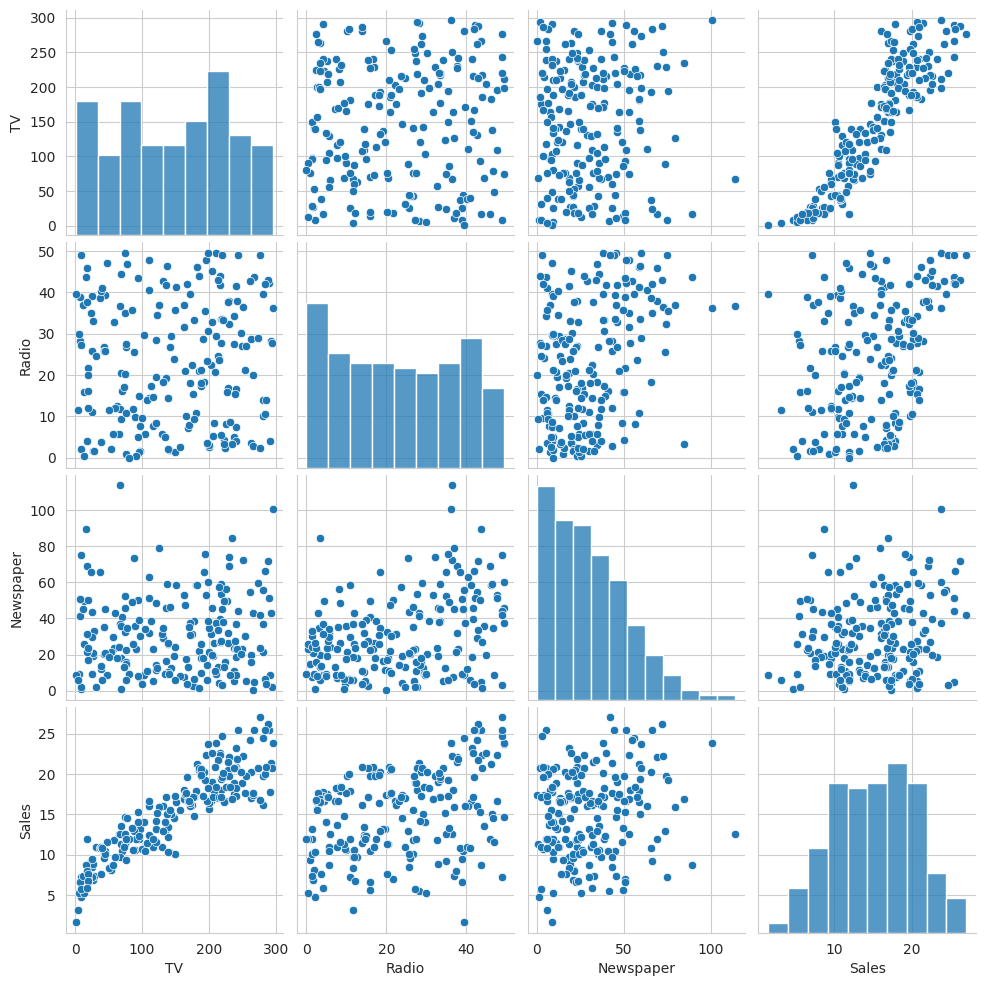

In [11]:
sns.pairplot(df)

plt.show()

## Correlation Heatmap

The correlation heatmap helps identify how strongly advertising channels are related to sales.

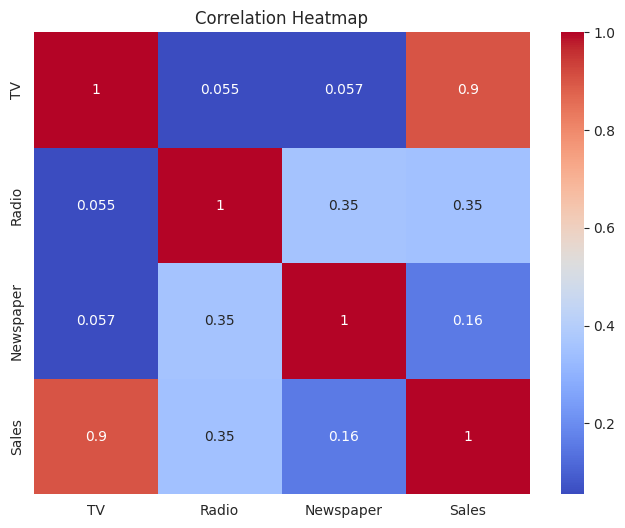

In [12]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

## TV Advertising and Sales

This visualization shows the relationship between TV advertising expenditure and sales.

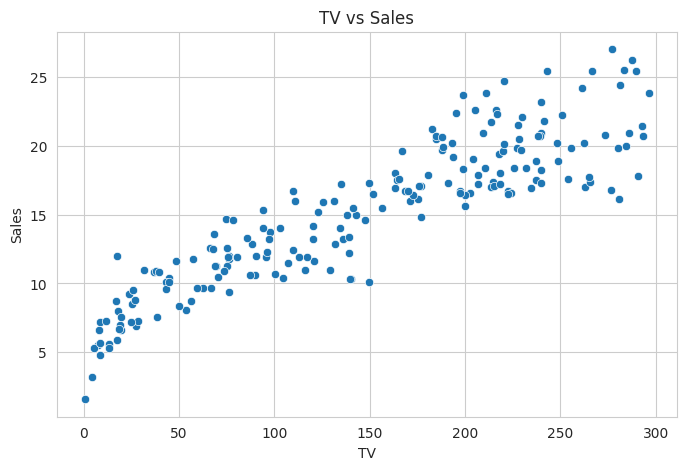

In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='TV',
    y='Sales',
    data=df
)

plt.title("TV vs Sales")

plt.show()

## Radio and Sales

This visualization shows the relationship between Radio expenditure and sales.

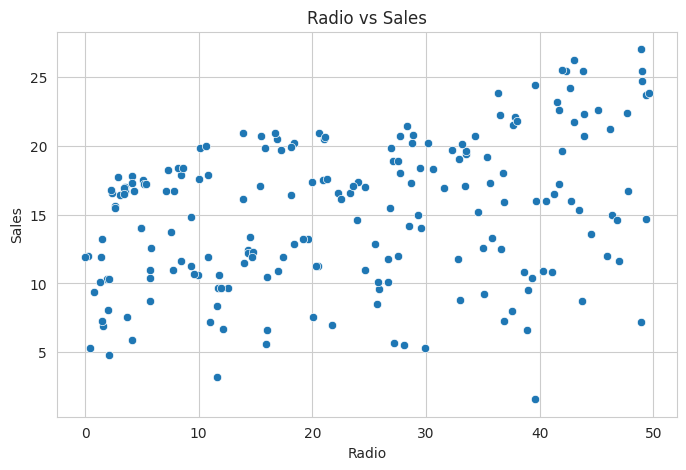

In [14]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Radio',
    y='Sales',
    data=df
)

plt.title("Radio vs Sales")

plt.show()

## Newspaper vs Sales

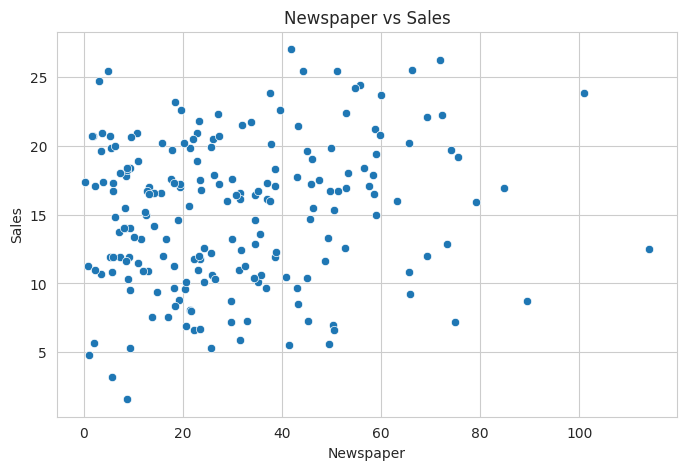

In [15]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Newspaper',
    y='Sales',
    data=df
)

plt.title("Newspaper vs Sales")

plt.show()

## Feature Selection

The independent variables are TV, Radio, and Newspaper advertising budget.

The dependent variable is Sales.

In [16]:
X = df[['TV', 'Radio', 'Newspaper']]

y = df['Sales']

## Splitting the Dataset

The dataset is divided into training and testing sets.

Training data is used to build the model, while testing data is used to evaluate performance.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Linear Regression Model

Linear Regression is a supervised machine learning algorithm used to predict continuous values.

In [18]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

## Predicting Sales

The trained model is used to predict sales for testing data.

In [19]:
y_pred = model.predict(X_test)

y_pred[:10]

array([17.0347724 , 20.40974033, 23.72398873,  9.27278518, 21.68271879,
       12.56940161, 21.08119452,  8.69035045, 17.23701254, 16.66657475])

## Model Evaluation

We evaluate the model using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R-Squared Score

In [20]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1.2748262109549338
RMSE: 1.7052146229349223
R2 Score: 0.9059011844150826


## Actual vs Predicted Sales

This plot compares actual sales values with predicted sales values.

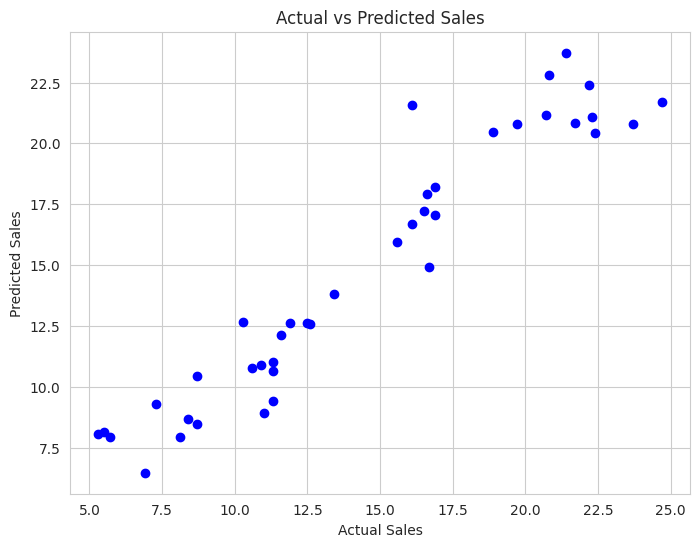

In [21]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    color='blue'
)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

# Key Findings

1. TV advertising has the strongest positive relationship with sales.

2. Radio advertising also contributes significantly to sales.

3. Newspaper advertising has a relatively weaker influence.

4. Linear Regression provides accurate sales predictions.

5. Advertising expenditure is positively associated with sales performance.

# Business Recommendations

1. Increase investment in TV advertising campaigns.

2. Continue optimizing radio advertisements.

3. Evaluate the return on investment from newspaper advertising.

4. Use predictive analytics to improve marketing decisions.

5. Allocate resources toward the most effective advertising channels.

# Conclusion

This project successfully developed a Sales Prediction model using Linear Regression.

The analysis demonstrated that advertising expenditure, particularly TV advertising, plays a major role in driving sales performance.

The machine learning model can help businesses forecast future sales and optimize marketing budgets more effectively.